In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [2]:

df = pd.read_csv(
    r"C:\Users\Amaan\OneDrive\Desktop\telecom\Customer-Churn-Prediction-Lifetime-Value-Engine\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df = df.dropna()

print("Dataset shape:", df.shape)

Dataset shape: (7032, 21)


In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"Yes": 1, "No": 0})

X = pd.get_dummies(X, drop_first=True)

X = X.astype(float)

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7032, 7061)
Target: (7032,)


In [2]:
import os

output_path = r"C:\Users\Amaan\OneDrive\Desktop\telecom\Customer-Churn-Prediction-Lifetime-Value-Engine\data\processed\customer_risk_scores.csv"

os.makedirs(os.path.dirname(output_path), exist_ok=True)

risk_df.to_csv(output_path, index=False)

print("Risk scoring file saved successfully!")

NameError: name 'risk_df' is not defined

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Risk scoring model trained successfully!")

Risk scoring model trained successfully!


c:\Users\Amaan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
churn_probability = model.predict_proba(X)[:, 1]

risk_df = df[["customerID"]].copy()

risk_df["Churn_Probability"] = churn_probability
risk_df["Churn_Probability_%"] = churn_probability * 100

risk_df.head(10)

,customerID,Churn_Probability,Churn_Probability_%
0,7590-VHVEG,0.370018,37.001784
1,5575-GNVDE,0.089117,8.911693
2,3668-QPYBK,0.511395,51.139537
3,7795-CFOCW,0.016482,1.648207
4,9237-HQITU,0.660022,66.002243
5,9305-CDSKC,0.808847,80.884736
6,1452-KIOVK,0.514164,51.416371
7,6713-OKOMC,0.245159,24.515869
8,7892-POOKP,0.620218,62.021805
9,6388-TABGU,0.024986,2.498603


In [ ]:

def risk_category(probability):
    if probability < 0.30:
        return "Low Risk"
    elif probability < 0.60:
        return "Medium Risk"
    else:
        return "High Risk"

risk_df["Risk_Category"] = risk_df["Churn_Probability"].apply(risk_category)

risk_df.head(10)

,customerID,Churn_Probability,Churn_Probability_%,Risk_Category
0,7590-VHVEG,0.370018,37.001784,Medium Risk
1,5575-GNVDE,0.089117,8.911693,Low Risk
2,3668-QPYBK,0.511395,51.139537,Medium Risk
3,7795-CFOCW,0.016482,1.648207,Low Risk
4,9237-HQITU,0.660022,66.002243,High Risk
5,9305-CDSKC,0.808847,80.884736,High Risk
6,1452-KIOVK,0.514164,51.416371,Medium Risk
7,6713-OKOMC,0.245159,24.515869,Low Risk
8,7892-POOKP,0.620218,62.021805,High Risk
9,6388-TABGU,0.024986,2.498603,Low Risk


In [ ]:
risk_counts = risk_df["Risk_Category"].value_counts()

print("Customer Risk Distribution:\n")
print(risk_counts)

Customer Risk Distribution:

Risk_Category
Low Risk       4241
Medium Risk    1776
High Risk      1015
Name: count, dtype: int64


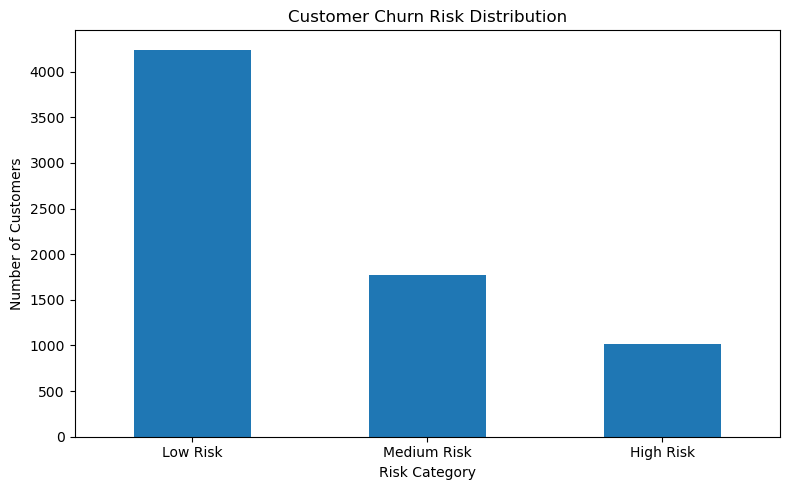

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
risk_counts.plot(kind="bar")

plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Risk Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
import os

output_path = r"C:\Users\Amaan\OneDrive\Desktop\telecom\Customer-Churn-Prediction-Lifetime-Value-Engine\data\processed\customer_risk_scores.csv"

os.makedirs(os.path.dirname(output_path), exist_ok=True)

risk_df.to_csv(output_path, index=False)

print("Risk scoring file saved successfully!")

Risk scoring file saved successfully!
